Paquetes necesarios

In [17]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

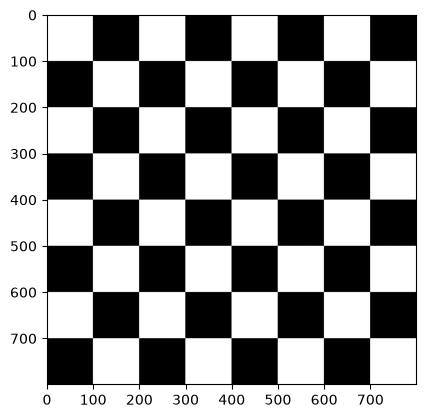

In [ ]:
#SIN IA

ancho = 800
alto = 800

chess_img = np.zeros((alto,ancho,1), dtype = np.uint8)

for i in range (8):
    inicio = i * 100
    fin = (i+1) *100
    if (i%2 == 0):
        chess_img [inicio:fin, 0:100] = 255
        chess_img [inicio:fin, 200:300] = 255
        chess_img [inicio:fin, 400:500] = 255
        chess_img [inicio:fin, 600:700] = 255

    else:
        chess_img [inicio:fin, 100:200] = 255
        chess_img [inicio:fin, 300:400] = 255
        chess_img [inicio:fin, 500:600] = 255
        chess_img [inicio:fin, 700:800] = 255


plt.imshow(chess_img, cmap='gray',vmin=0, vmax=255)
plt.show()


TAREA 1 CON IA

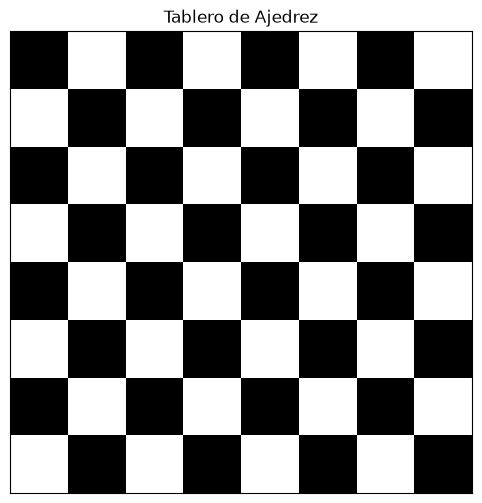

In [19]:
tablero = np.zeros((8, 8))

# 2. Rellenar con unos (1 representará el color blanco) de forma alterna
# Modificamos las filas impares, columnas pares
tablero[1::2, 0::2] = 1
# Modificamos las filas pares, columnas impares
tablero[0::2, 1::2] = 1

# 3. Configurar y dibujar el tablero
plt.figure(figsize=(6, 6)) # Define un tamaño cuadrado para la ventana
plt.imshow(tablero, cmap='gray', interpolation='nearest')

# 4. Limpiar la interfaz (opcional pero recomendado)
# Esto quita los números de los ejes X e Y para que se vea más limpio
plt.xticks([])
plt.yticks([])

# 5. Mostrar el resultado
plt.title("Tablero de Ajedrez")
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

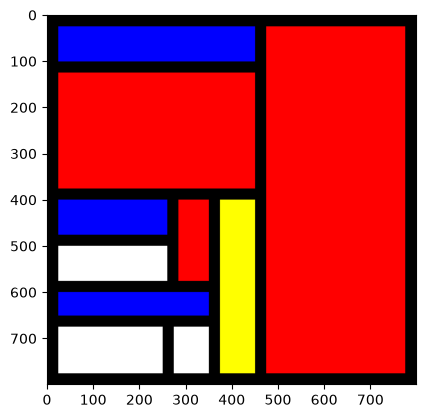

In [20]:
# TAREA 2

Mondrian_img = np.zeros((alto,ancho,3), dtype = np.uint8)
#cv2.line(Mondrian_img)

#LINEA HORIZONTAL AZUL 
cv2.rectangle(Mondrian_img,(25,25),(450,100),(0,0,255),-1)
#Rectangulo ROJO derecha
cv2.rectangle(Mondrian_img,(475,25),(775,775),(255,0,0),-1)
#rectagulo blanco
cv2.rectangle(Mondrian_img,(25,775),(250,675),(255,255,255),-1)
#rectagulo blanco pequeño
cv2.rectangle(Mondrian_img,(275,775),(350,675),(255,255,255),-1)

#rectangulo amarillo
cv2.rectangle(Mondrian_img,(375,775),(450,400),(255,255,0),-1)

#rectangulo rojo derecha
cv2.rectangle(Mondrian_img,(25,125),(450,375),(255,0,0),-1)
#rectangulo azul
cv2.rectangle(Mondrian_img,(25,650),(350,600),(0,0,255),-1)
#rectangulo blanco
cv2.rectangle(Mondrian_img,(25,575),(260,500),(255,255,255),-1)
#rectangulo rojo
cv2.rectangle(Mondrian_img,(285,575),(350,400),(255,0,0),-1)
#rectangulo azul
cv2.rectangle(Mondrian_img,(25,475),(260,400),(0,0,255),-1)


plt.imshow(Mondrian_img) 
plt.show()

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [21]:
#TAREA 3
vid = cv2.VideoCapture(0)

font = cv2.FONT_HERSHEY_SIMPLEX
  
while(True):      
   
    ret, frame = vid.read()

    if  ret: 

        alto, ancho, _ = frame.shape

 
        min_brillo = 766    
        max_brillo = -1
        min_loc = (0, 0)    # minimo actual
        max_loc = (0, 0)    # maximo actual

    # Recorrido píxel a píxel 
        for y in range(alto):
            for x in range(ancho):
                b = int(frame[y, x, 0])
                g = int(frame[y, x, 1])
                r = int(frame[y, x, 2])
            
                brillo = b + g + r

            # Comprobamos el más oscuro
                if brillo < min_brillo:
                    min_brillo = brillo
                    min_loc = (x, y)

            # Comprobamos el más claro
                if brillo > max_brillo:
                    max_brillo = brillo
                    max_loc = (x, y)

    
        cv2.circle(frame, max_loc, 10, (255, 0, 0), 2)
        cv2.circle(frame, min_loc, 10, (0, 0, 0), 2)


        cv2.imshow('Cam', frame)   
        
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [22]:
vid = cv2.VideoCapture(0)

w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

w=int(w/2)
h=int(h/2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) 
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)


collage = np.zeros((h*2,w*2,3), dtype = np.uint8)
tl = collage[0:h,0:w]
tr = collage[0:h,w:w+w]
bl = collage[h:h+h,0:w]
br = collage[h:h+h,w:w+w]

while True:      

    ret, frameIN = vid.read()

    
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]

        #Jugamos con los valores de los planos
        tl[:,:,0] = b
        tl[:,:,1] = g
        tl[:,:,2] = r - r 

        tr[:,:,0] = r
        tr[:,:,1] = 255 - g
        tr[:,:,2] = 255 - b
        
        bl[:,:,0] = 255 - r
        bl[:,:,1] = 255 - b 
        bl[:,:,2] = g

        br[:,:,0] = b
        br[:,:,1] = g
        br[:,:,2] = 255 - r
    
       
        cv2.imshow('Cam', collage)
    
    
    if cv2.waitKey(20) == 27:
        break
  

vid.release()
cv2.destroyAllWindows()